In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle

df = pd.read_csv('../data/processed/survey_engineered.csv')
print(f"Shape: {df.shape}")
df.head()

Shape: (42723, 29)


,EdLevel,YearsCodePro,Employment,DevType,OrgSize,ConvertedCompYearly,Country_Australia,Country_Austria,Country_Belgium,Country_Brazil,...,Country_New Zealand,Country_Norway,Country_Other,Country_Poland,Country_Portugal,Country_Spain,Country_Sweden,Country_Switzerland,Country_United Kingdom of Great Britain and Northern Ireland,Country_United States of America
0,1,23.0,0,11,6,250000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,7.0,0,14,3,156000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1,4.0,2,15,5,23456.0,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
3,3,21.0,0,11,3,96828.0,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,3,3.0,0,15,0,135000.0,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [78]:
# X = everything the model USES to make predictions (features/inputs)
# y = what the model is TRYING to predict (target/output)
X = df.drop('ConvertedCompYearly', axis=1)  # Everything EXCEPT salary
y = df['ConvertedCompYearly']               # ONLY salary

print(f"X Shape: {X.shape}")
print(f"y Shape: {y.shape}")
print(f"\nFeatures we're using to predict salary:")
for col in X.columns:
    print(f"  → {col}")

X Shape: (42723, 28)
y Shape: (42723,)

Features we're using to predict salary:
  → EdLevel
  → YearsCodePro
  → Employment
  → DevType
  → OrgSize
  → Country_Australia
  → Country_Austria
  → Country_Belgium
  → Country_Brazil
  → Country_Canada
  → Country_Czech Republic
  → Country_Denmark
  → Country_Finland
  → Country_France
  → Country_Germany
  → Country_India
  → Country_Italy
  → Country_Netherlands
  → Country_New Zealand
  → Country_Norway
  → Country_Other
  → Country_Poland
  → Country_Portugal
  → Country_Spain
  → Country_Sweden
  → Country_Switzerland
  → Country_United Kingdom of Great Britain and Northern Ireland
  → Country_United States of America


In [79]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,
    random_state=42
)

print(f"Training Set: {X_train.shape[0]:,} rows")
print(f"Testing Set: {X_test.shape[0]:,} rows")
print(f"\nThe model will NEVER see the test set during training!")

Training Set: 34,178 rows
Testing Set: 8,545 rows

The model will NEVER see the test set during training!


In [80]:
def evaluate_model(name, model, X_test, y_test):
    """
    Takes a trained model and prints 3 key metrics:
    - MAE  : Mean Absolute Error (in dollars — easiest to understand!)
    - RMSE : Root Mean Squared Error (punishes big mistakes more)
    - R²   : How much of salary variance the model explains (0 to 1)
    """
    predictions = model.predict(X_test)
    
    mae  = mean_absolute_error(y_test, predictions)
    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2   = r2_score(y_test, predictions)
    
    print(f"\n{'='*45}")
    print(f"{name}".center(45))
    print(f"{'='*45}")
    print(f"  MAE  : ${mae:>10,.0f}   ← avg prediction error")
    print(f"  RMSE : ${rmse:>10,.0f}   ← error (penalizes big mistakes)")
    print(f"  R²   : {r2:>10.3f}   ← 1.0 = perfect, 0.0 = useless")
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2}

In [81]:
print("Training Linear Regression...")
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_results = evaluate_model("Linear Regression", lr_model, X_test, y_test)

Training Linear Regression...

              Linear Regression              
  MAE  : $    28,318   ← avg prediction error
  RMSE : $    38,197   ← error (penalizes big mistakes)
  R²   :      0.492   ← 1.0 = perfect, 0.0 = useless


In [82]:
print("Training Decision Tree...")
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

dt_results = evaluate_model("Decision Tree", dt_model, X_test, y_test)

Training Decision Tree...

                Decision Tree                
  MAE  : $    33,532   ← avg prediction error
  RMSE : $    46,705   ← error (penalizes big mistakes)
  R²   :      0.241   ← 1.0 = perfect, 0.0 = useless


In [83]:
print("Training Random Forest...")
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)
rf_model.fit(X_train, y_train)

rf_results = evaluate_model("Random Forest", rf_model, X_test, y_test)

Training Random Forest...

                Random Forest                
  MAE  : $    27,348   ← avg prediction error
  RMSE : $    37,527   ← error (penalizes big mistakes)
  R²   :      0.510   ← 1.0 = perfect, 0.0 = useless


In [84]:
print("Training Gradient Boosting...")
gb_model = GradientBoostingRegressor(
    n_estimators=600,
    learning_rate=0.1,
    random_state=42
)
gb_model.fit(X_train, y_train)

gb_results = evaluate_model("Gradient Boosting", gb_model, X_test, y_test)

Training Gradient Boosting...

              Gradient Boosting              
  MAE  : $    24,790   ← avg prediction error
  RMSE : $    33,931   ← error (penalizes big mistakes)
  R²   :      0.599   ← 1.0 = perfect, 0.0 = useless



MODEL COMPARISON (sorted by MAE)
             name          MAE         RMSE       R2
Gradient Boosting 24789.884564 33931.463227 0.599210
    Random Forest 27347.648708 37527.093907 0.509768
Linear Regression 28318.240781 38196.656101 0.492119
    Decision Tree 33532.119874 46705.294456 0.240647


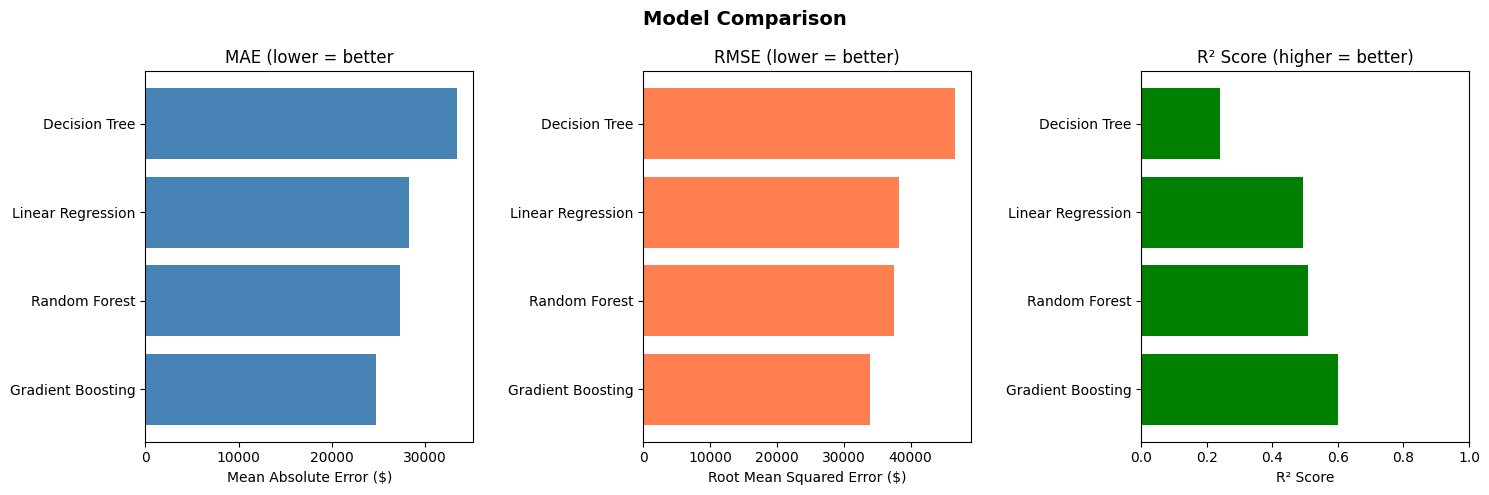

In [85]:
# Models Comparison
results = pd.DataFrame([lr_results, dt_results, rf_results, gb_results])
results = results.sort_values('MAE')

print("\nMODEL COMPARISON (sorted by MAE)")
print(results.to_string(index=False))

# Visualize the Comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# MAE Comparison
axes[0].barh(results['name'], results['MAE'], color='steelblue')
axes[0].set_title('MAE (lower = better')
axes[0].set_xlabel('Mean Absolute Error ($)')

# RMSE Comparison
axes[1].barh(results['name'], results['RMSE'], color='coral')
axes[1].set_title('RMSE (lower = better)')
axes[1].set_xlabel('Root Mean Squared Error ($)')

# R² comparison
axes[2].barh(results['name'], results['R2'], color='green')
axes[2].set_title('R² Score (higher = better)')
axes[2].set_xlabel('R² Score')
axes[2].set_xlim(0, 1)

plt.suptitle('Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

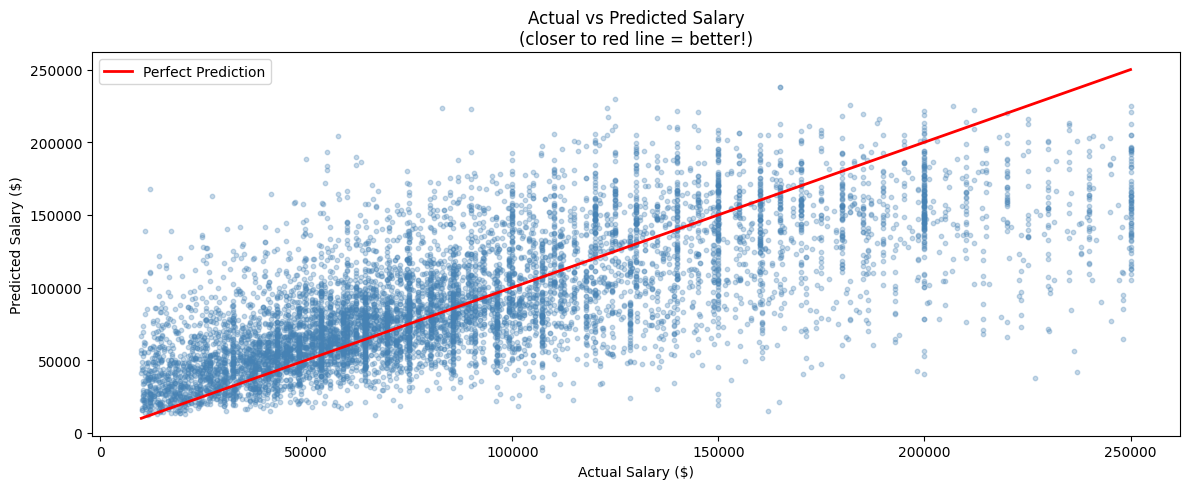

Where the model struggles most:
  Very high salaries (>$200k): avg error = $79,075
  Mid salaries ($50k-$150k):   avg error = $23,959
  Lower salaries (<$50k):      avg error = $22,367


In [ ]:
# Use the best model
best_model = gb_model
predictions = best_model.predict(X_test)

plt.figure(figsize=(12, 5))
plt.scatter(y_test, predictions, alpha=0.3, color='steelblue', s=10)

# The perfect prediction line — if every prediction was exact,
# all dots would sit perfectly on this diagonal line!
plt.plot([10000, 250000], [10000, 250000],
         color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Salary ($)')
plt.ylabel('Predicted Salary ($)')
plt.title('Actual vs Predicted Salary\n(closer to red line = better!)')
plt.legend()
plt.tight_layout()
plt.show()

# Where is the model most wrong?
errors = np.abs(predictions - y_test)
print(f"Where the model struggles most:")
print(f"  Very high salaries (>$200k): avg error = ${errors[y_test > 200000].mean():,.0f}")
print(f"  Mid salaries ($50k-$150k):   avg error = ${errors[(y_test > 50000) & (y_test < 150000)].mean():,.0f}")
print(f"  Lower salaries (<$50k):      avg error = ${errors[y_test < 50000].mean():,.0f}")

In [ ]:
# Save the best performing model
best_model = gb_model

with open('../data/processed/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("Best model saved to data/processed/best_model.pkl")

# Verify it loads correctly
with open('../data/processed/best_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

# Make a test prediction
test_prediction = loaded_model.predict(X_test.iloc[[0]])
actual = y_test.iloc[0]
print(f"\nQuick sanity check:")
print(f"  Predicted: ${test_prediction[0]:,.0f}")
print(f"  Actual:    ${actual:,.0f}")
print(f"  Error:     ${abs(test_prediction[0] - actual):,.0f}")

Best model saved to data/processed/best_model.pkl

Quick sanity check:
  Predicted: $99,156
  Actual:    $105,766
  Error:     $6,610
